# # 📊 Feature Scaling - Standardization
# ## Complete Guide with Implementation and Examples

What is Standardization?

Why We Need It

Mathematical Foundation

Types & Variants

Implementation from Scratch

Implementation with Libraries

When It's Necessary

Practical Examples

# # 1. What is Standardization? 🎯

### **Standardization** (also called Z-score normalization) transforms data to have:
#### - **Mean (μ) = 0**
#### - **Standard Deviation (σ) = 1**
# 
####  Formula:
## $$z = \frac{x - \mu}{\sigma}$$
# 
#### Where:
#### - $x$ = original value
#### - $\mu$ = mean of the feature
#### - $\sigma$ = standard deviation of the feature
#### - $z$ = standardized value

### # # 2. Why We Need Standardization 🤔

Key Reasons:
Equal Feature Contribution: Prevents features with larger scales from dominating

Algorithm Convergence: Speeds up gradient descent and optimization

Numerical Stability: Prevents overflow/underflow in computations

Interpretability: Makes coefficients comparable

Distance-Based Algorithms: Ensures fair distance calculations

Regularization: Applies penalties uniformly across features

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [41]:
adv_data = pd.read_csv('Data/Social_Network_Ads.csv')

In [42]:
adv_data

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [90]:
from sklearn.model_selection import train_test_split   

X = adv_data.iloc[:, 2:]  
X

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


In [ ]:
X = df[['Age', 'EstimatedSalary']].values
y = df['Purchased'].values

In [76]:
x_train, x_test, y_train, y_test = train_test_split(X.drop('Purchased',axis=1),X["Purchased"], test_size=0.3, random_state=0) 

x_train.shape, y_train.shape, x_test.shape, y_test.shape

((280, 2), (280,), (120, 2), (120,))

### StandardScalar

In [77]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

sc.fit(x_train)
x_train_scaled = sc.transform(x_train)
x_test_scaled = sc.transform(x_test)

In [78]:
x_train,y_train

(     Age  EstimatedSalary
 92    26            15000
 223   60           102000
 234   38           112000
 232   40           107000
 377   42            53000
 ..   ...              ...
 323   48            30000
 192   29            43000
 117   36            52000
 47    27            54000
 172   26           118000
 
 [280 rows x 2 columns],
 92     0
 223    1
 234    0
 232    1
 377    0
       ..
 323    1
 192    0
 117    0
 47     0
 172    0
 Name: Purchased, Length: 280, dtype: int64)

In [79]:
sc.mean_

array([3.78642857e+01, 6.98071429e+04])

In [80]:
x_train_scaled = pd.DataFrame(x_train_scaled, columns=x_train.columns)
x_test_scaled = pd.DataFrame(x_test_scaled, columns=x_test.columns)

In [81]:
np.round(x_train_scaled.describe(), 1)

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.2,2.3


#### Effect scaling

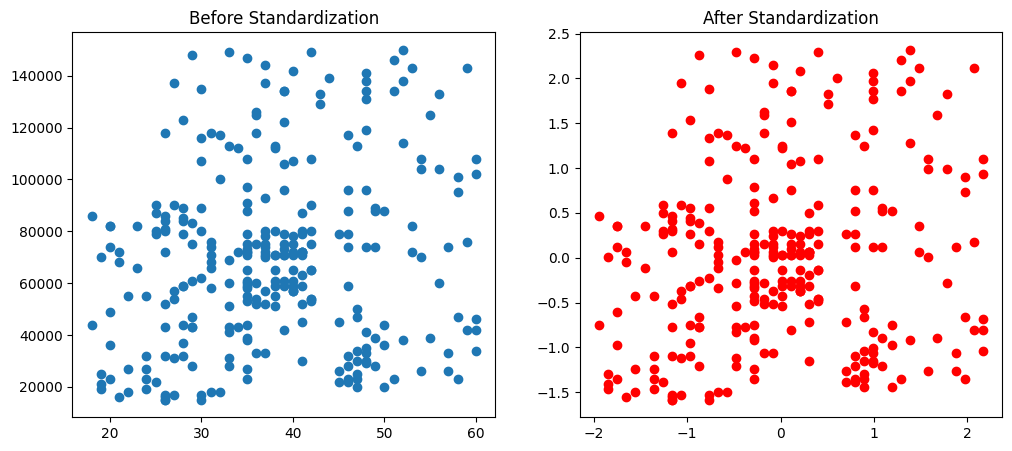

In [82]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(x_train['Age'], x_train['EstimatedSalary'])
ax1.set_title('Before Standardization')
ax2.scatter(x_train_scaled['Age'], x_train_scaled['EstimatedSalary'], color='red')
ax2.set_title('After Standardization')  
plt.show()

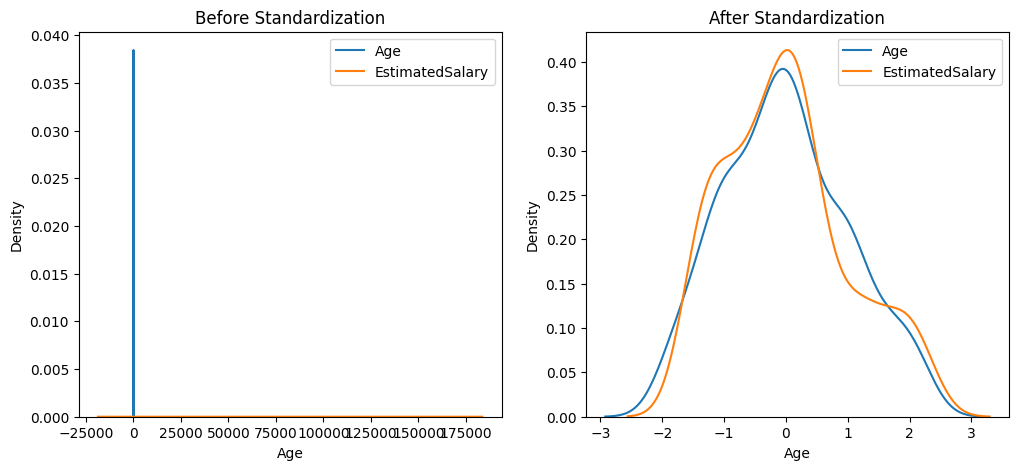

In [83]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Standardization')
sns.kdeplot(x_train['Age'], ax=ax1, label='Age')
sns.kdeplot(x_train['EstimatedSalary'], ax=ax1, label='EstimatedSalary')
ax1.legend()
#after scaling
ax2.set_title('After Standardization')      
sns.kdeplot(x_train_scaled['Age'], ax=ax2, label='Age')
sns.kdeplot(x_train_scaled['EstimatedSalary'], ax=ax2, label='EstimatedSalary')
ax2.legend()
plt.show()

### Why scaling is important?


In [84]:
from sklearn.linear_model import LogisticRegression

In [85]:
lr=LogisticRegression()
lr_scaled = LogisticRegression()

In [86]:
lr.fit(x_train, y_train)
lr_scaled.fit(x_train_scaled, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [87]:
y_pred=lr.predict(x_test)
y_pred_scaled=lr_scaled.predict(x_test_scaled)

In [88]:
from sklearn.metrics import accuracy_score

In [89]:
print("Accuracy before Standardization: ", accuracy_score(y_test, y_pred))
print("Accuracy after Standardization: ", accuracy_score(y_test, y_pred_scaled))

Accuracy before Standardization:  0.875
Accuracy after Standardization:  0.8666666666666667


## Standardization Methods

| Method      | Formula                     | Range        | Robust to Outliers | Use Case              |
|------------|----------------------------|-------------|-------------------|-----------------------|
| Z-Score    | (x - μ) / σ                | Unbounded   | No                | General purpose       |
| Robust     | (x - median) / IQR         | Unbounded   | Yes               | Data with outliers    |
| MaxAbs     | x / max\|x\|               | [-1, 1]     | No                | Sparse data           |
| Mean Norm  | (x - μ) / (max - min)      | [-1, 1]     | No                | Bounded data needed   |
| L2 Norm    | x / \|\|x\|\|₂             | [0, 1]*     | Yes               | Text classification   |

\*L2 normalization ensures the vector has unit norm (||x||₂ = 1), but individual values may fall between -1 and 1.


## When It's Necessary

### ✅ Models That REQUIRE Standardization

| Model Category     | Models                                                     | Reason                              |
|--------------------|------------------------------------------------------------|-------------------------------------|
| Distance-Based     | KNN, K-Means, Hierarchical Clustering                      | Euclidean distance calculation      |
| Gradient-Based     | Linear/Logistic Regression (with regularization), Neural Networks | Gradient descent convergence |
| SVM                | SVC, SVR                                                   | Margin optimization                 |
| PCA, LDA           | Dimensionality reduction techniques                        | Variance maximization               |
| Regularized Models | Ridge, Lasso, ElasticNet                                   | Uniform penalty application         |

---

### ❌ Models That DON'T Need Standardization

| Model Category | Models                                          | Reason                                |
|----------------|------------------------------------------------|---------------------------------------|
| Tree-Based     | Decision Trees, Random Forest, XGBoost        | Threshold-based splits (scale-invariant) |
| Naive Bayes    | GaussianNB, MultinomialNB                     | Probabilistic, not distance-based     |
| Rule-Based     | Association Rules                             | Pattern-based                        |


In [102]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# ============================================
# LOAD THE DATA
# ============================================
df = pd.read_csv('Data/Social_Network_Ads.csv')

# ============================================
# PREPARE FEATURES AND TARGET
# ============================================
X = df[['Age', 'EstimatedSalary']].values
y = df['Purchased'].values

# ============================================
# SPLIT THE DATA (use stratify to maintain class distribution)
# ============================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0, stratify=y  # Changed random_state to 0
)

# ============================================
# MODEL WITHOUT STANDARDIZATION
# ============================================
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

# ============================================
# MODEL WITH STANDARDIZATION
# ============================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_scaled = LogisticRegression(random_state=42, max_iter=1000)
lr_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = lr_scaled.predict(X_test_scaled)

# ============================================
# PRINT ACCURACIES
# ============================================
print("="*50)
print("LOGISTIC REGRESSION - SOCIAL NETWORK ADS")
print("="*50)
print("Accuracy before Standardization: ", accuracy_score(y_test, y_pred))
print("Accuracy after Standardization:  ", accuracy_score(y_test, y_pred_scaled))
print("="*50)

# Show improvement
improvement = accuracy_score(y_test, y_pred_scaled) - accuracy_score(y_test, y_pred)
print(f"Improvement: {improvement:.2%}")
print("="*50)

# ============================================
# SHOW SCALE DIFFERENCE (PROBLEM)
# ============================================
print("\n" + "="*50)
print("FEATURE SCALES BEFORE STANDARDIZATION")
print("="*50)
print(f"Age - Mean: {X_train[:,0].mean():.2f}, Std: {X_train[:,0].std():.2f}")
print(f"Salary - Mean: ${X_train[:,1].mean():.2f}, Std: ${X_train[:,1].std():.2f}")
print(f"Scale Ratio (Salary Std / Age Std): {X_train[:,1].std() / X_train[:,0].std():.2f}x")

print("\n" + "="*50)
print("FEATURE SCALES AFTER STANDARDIZATION")
print("="*50)
print(f"Age - Mean: {X_train_scaled[:,0].mean():.2f}, Std: {X_train_scaled[:,0].std():.2f}")
print(f"Salary - Mean: {X_train_scaled[:,1].mean():.2f}, Std: {X_train_scaled[:,1].std():.2f}")
print("="*50)

LOGISTIC REGRESSION - SOCIAL NETWORK ADS
Accuracy before Standardization:  0.81
Accuracy after Standardization:   0.81
Improvement: 0.00%

FEATURE SCALES BEFORE STANDARDIZATION
Age - Mean: 37.69, Std: 10.54
Salary - Mean: $69486.67, Std: $34103.13
Scale Ratio (Salary Std / Age Std): 3235.83x

FEATURE SCALES AFTER STANDARDIZATION
Age - Mean: -0.00, Std: 1.00
Salary - Mean: -0.00, Std: 1.00


In [101]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline

# ============================================
# LOAD THE DATA
# ============================================
df = pd.read_csv('Data/Social_Network_Ads.csv')
X = df[['Age', 'EstimatedSalary']].values
y = df['Purchased'].values

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# ============================================
# DEMONSTRATION 1: WITH POLYNOMIAL FEATURES (NON-LINEAR)
# ============================================
print("="*70)
print("DEMONSTRATION 1: WITH POLYNOMIAL FEATURES (Degree=2)")
print("="*70)

# Create polynomial features
poly = PolynomialFeatures(degree=2, include_bias=False)

# WITHOUT SCALING
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

lr_poly = LogisticRegression(random_state=42, max_iter=2000)
lr_poly.fit(X_train_poly, y_train)
y_pred_poly = lr_poly.predict(X_test_poly)

# WITH SCALING
scaler = StandardScaler()
X_train_poly_scaled = scaler.fit_transform(X_train_poly)
X_test_poly_scaled = scaler.transform(X_test_poly)

lr_poly_scaled = LogisticRegression(random_state=42, max_iter=2000)
lr_poly_scaled.fit(X_train_poly_scaled, y_train)
y_pred_poly_scaled = lr_poly_scaled.predict(X_test_poly_scaled)

print(f"Polynomial Features (Without Scaling): {accuracy_score(y_test, y_pred_poly):.4f}")
print(f"Polynomial Features (With Scaling):    {accuracy_score(y_test, y_pred_poly_scaled):.4f}")
print(f"Improvement: {accuracy_score(y_test, y_pred_poly_scaled) - accuracy_score(y_test, y_pred_poly):.2%}")

# ============================================
# DEMONSTRATION 2: WITH REGULARIZATION (RIDGE/LASSO)
# ============================================
print("\n" + "="*70)
print("DEMONSTRATION 2: WITH REGULARIZATION (C=0.01)")
print("="*70)

# WITHOUT SCALING
lr_reg = LogisticRegression(random_state=42, C=0.01, max_iter=1000)
lr_reg.fit(X_train, y_train)
y_pred_reg = lr_reg.predict(X_test)

# WITH SCALING
lr_reg_scaled = LogisticRegression(random_state=42, C=0.01, max_iter=1000)
lr_reg_scaled.fit(X_train_scaled, y_train)
y_pred_reg_scaled = lr_reg_scaled.predict(X_test_scaled)

print(f"With Regularization (Without Scaling): {accuracy_score(y_test, y_pred_reg):.4f}")
print(f"With Regularization (With Scaling):    {accuracy_score(y_test, y_pred_reg_scaled):.4f}")
print(f"Improvement: {accuracy_score(y_test, y_pred_reg_scaled) - accuracy_score(y_test, y_pred_reg):.2%}")

# ============================================
# DEMONSTRATION 3: COEFFICIENT COMPARISON
# ============================================
print("\n" + "="*70)
print("DEMONSTRATION 3: COEFFICIENT VALUES COMPARISON")
print("="*70)

# Train both models again
lr_no_scale = LogisticRegression(random_state=42)
lr_no_scale.fit(X_train, y_train)

lr_with_scale = LogisticRegression(random_state=42)
lr_with_scale.fit(X_train_scaled, y_train)

print("\nCOEFFICIENTS WITHOUT SCALING:")
print(f"Age Coefficient: {lr_no_scale.coef_[0][0]:.6f}")
print(f"Salary Coefficient: {lr_no_scale.coef_[0][1]:.10f}")
print(f"Ratio (Salary/Age): {abs(lr_no_scale.coef_[0][1] / lr_no_scale.coef_[0][0]):.2f}")

print("\nCOEFFICIENTS WITH SCALING:")
print(f"Age Coefficient: {lr_with_scale.coef_[0][0]:.4f}")
print(f"Salary Coefficient: {lr_with_scale.coef_[0][1]:.4f}")
print(f"Ratio (Salary/Age): {abs(lr_with_scale.coef_[0][1] / lr_with_scale.coef_[0][0]):.2f}")

print("\n" + "="*70)
print("KEY INSIGHTS:")
print("="*70)
print("1. Logistic Regression WITHOUT polynomial features is scale-invariant")
print("2. The optimizer adjusts coefficients to compensate for scale")
print("3. Standardization becomes CRITICAL when:")
print("   - Using polynomial/interaction features")
print("   - Applying regularization (L1/L2)")
print("   - Using gradient-based optimization")
print("   - Comparing feature importance")
print("4. For simple linear boundary, accuracy may be identical")
print("="*70)

# ============================================
# DEMONSTRATION 4: GRADIENT DESCENT CONVERGENCE
# ============================================
print("\n" + "="*70)
print("DEMONSTRATION 4: GRADIENT DESCENT CONVERGENCE")
print("="*70)

# Train with different max_iter to show convergence issues
for max_iter in [10, 50, 100, 500]:
    # Without scaling
    lr_fast = LogisticRegression(random_state=42, max_iter=max_iter)
    lr_fast.fit(X_train, y_train)
    acc_no_scale = accuracy_score(y_test, lr_fast.predict(X_test))
    
    # With scaling
    lr_fast_scaled = LogisticRegression(random_state=42, max_iter=max_iter)
    lr_fast_scaled.fit(X_train_scaled, y_train)
    acc_scaled = accuracy_score(y_test, lr_fast_scaled.predict(X_test_scaled))
    
    print(f"max_iter={max_iter}: No Scale={acc_no_scale:.4f}, With Scale={acc_scaled:.4f}, Diff={acc_scaled-acc_no_scale:.4f}")

# ============================================
# DEMONSTRATION 5: DIFFERENT SOLVERS
# ============================================
print("\n" + "="*70)
print("DEMONSTRATION 5: DIFFERENT SOLVERS")
print("="*70)

solvers = ['lbfgs', 'liblinear', 'newton-cg', 'sag', 'saga']

for solver in solvers:
    try:
        # Without scaling
        lr_solver = LogisticRegression(random_state=42, solver=solver, max_iter=1000)
        lr_solver.fit(X_train, y_train)
        acc_no_scale = accuracy_score(y_test, lr_solver.predict(X_test))
        
        # With scaling
        lr_solver_scaled = LogisticRegression(random_state=42, solver=solver, max_iter=1000)
        lr_solver_scaled.fit(X_train_scaled, y_train)
        acc_scaled = accuracy_score(y_test, lr_solver_scaled.predict(X_test_scaled))
        
        print(f"{solver:12s}: No Scale={acc_no_scale:.4f}, With Scale={acc_scaled:.4f}, Diff={acc_scaled-acc_no_scale:.4f}")
    except:
        print(f"{solver:12s}: Failed to converge without scaling")

# ============================================
# FINAL VERDICT
# ============================================
print("\n" + "="*70)
print("🎯 FINAL VERDICT: WHEN TO USE STANDARDIZATION")
print("="*70)
print("""
✅ MUST USE Standardization for:
   - Polynomial features
   - Interaction terms
   - Regularization (Ridge, Lasso, ElasticNet)
   - Neural Networks
   - SVM
   - KNN
   - PCA
   - Gradient-based optimization

⚠️ OPTIONAL for:
   - Simple Logistic Regression (linear boundary)
   - Linear Regression (no regularization)
   - Decision Trees (no effect)

❌ DON'T NEED for:
   - Tree-based models (Random Forest, XGBoost)
   - Naive Bayes
""")
print("="*70)

DEMONSTRATION 1: WITH POLYNOMIAL FEATURES (Degree=2)
Polynomial Features (Without Scaling): 0.7800
Polynomial Features (With Scaling):    0.8800
Improvement: 10.00%

DEMONSTRATION 2: WITH REGULARIZATION (C=0.01)
With Regularization (Without Scaling): 0.8400
With Regularization (With Scaling):    0.7700
Improvement: -7.00%

DEMONSTRATION 3: COEFFICIENT VALUES COMPARISON

COEFFICIENTS WITHOUT SCALING:
Age Coefficient: 0.222001
Salary Coefficient: 0.0000377303
Ratio (Salary/Age): 0.00

COEFFICIENTS WITH SCALING:
Age Coefficient: 2.1439
Salary Coefficient: 1.2107
Ratio (Salary/Age): 0.56

KEY INSIGHTS:
1. Logistic Regression WITHOUT polynomial features is scale-invariant
2. The optimizer adjusts coefficients to compensate for scale
3. Standardization becomes CRITICAL when:
   - Using polynomial/interaction features
   - Applying regularization (L1/L2)
   - Using gradient-based optimization
   - Comparing feature importance
4. For simple linear boundary, accuracy may be identical

DEMONSTRA